<a href="https://colab.research.google.com/github/Naylet92/Estudio_ambiental/blob/main/Colima/NCL_guardar_numpy_en_geotiff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Analisis Nevado de Colima

 Script para guardar datos en Numpy arrays como GeoTIFFs con los mismo parámetros de georefferenciación que una imagen de referencia proporcionado

In [2]:
PREFIJO = "NCL"

## Ruta para una icarpeta de datos GeoTIFF
RUTA_TIF = '/content/drive/MyDrive/Colab Data NDC 2020'

## Nombre del archivo GeoTIFF de referencia
ref_tiff_name = f'{PREFIJO}_2020_L8_seca.tif'

## Ruta para una carpeta de datos NumPy array
RUTA_DATOS = '/content/drive/MyDrive/Colab Data NDC 2020/Numpy'

## Nombres de NumPy arrays
numpy_file_names = [
    f"2020_{PREFIJO}_ANN_prediction.npy",
    f"2010_{PREFIJO}_ANN_prediction.npy",
    f"2000_{PREFIJO}_ANN_prediction.npy"
]


In [3]:
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
from osgeo import gdal, osr

drive.mount('/content/drive')

Mounted at /content/drive


File: 2020_NCL_ANN_prediction.npy, Shape: (445, 778)


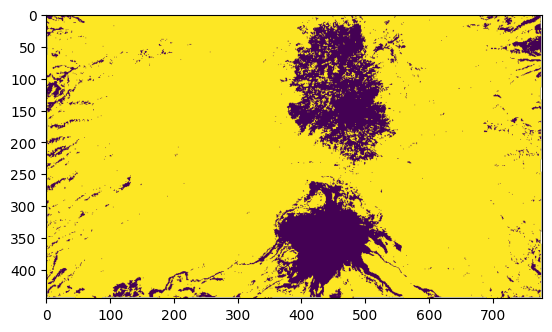

File: 2010_NCL_ANN_prediction.npy, Shape: (445, 778)


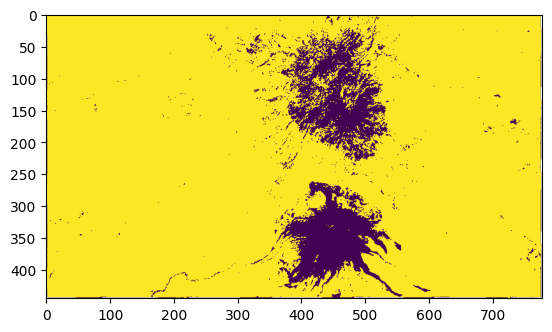

File: 2000_NCL_ANN_prediction.npy, Shape: (445, 778)


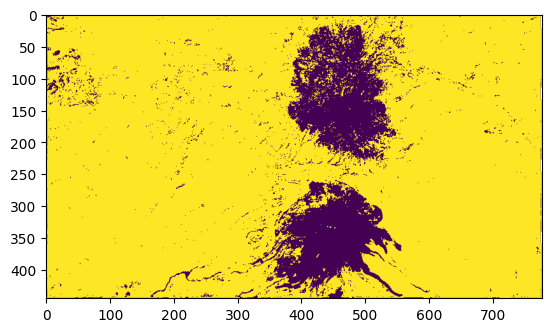

In [7]:
loaded_arrays = {}
for filename in numpy_file_names:
    file_path = f"{RUTA_DATOS}/{filename}"
    try:
        data = np.load(file_path)
        loaded_arrays[filename] = data
        print(f"File: {filename}, Shape: {data.shape}")
        plt.imshow(data[:,:])
        plt.show()
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"Error loading {filename}: {e}")

/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Reference GeoTIFF: NCL_2020_L8_seca.tif
  Geotransform: (631560.0, 30.0, 0.0, 2168220.0, 0.0, -30.0)
  Projection (WKT): PROJCS["WGS 84 / UTM zone 13N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"...
  Pixel Dimensions (Width x Height): 778 x 445


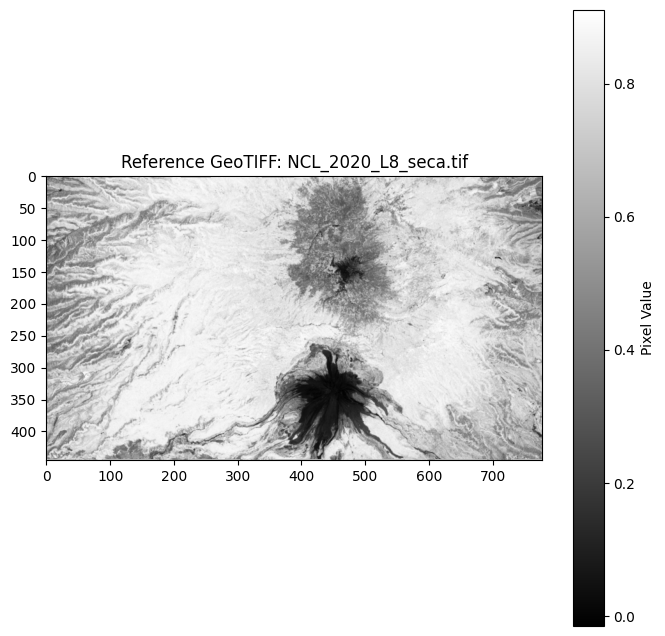

In [9]:
ref_tiff_path = f"{RUTA_TIF}/{ref_tiff_name}"

try:
    ds = gdal.Open(ref_tiff_path)
    if ds is None:
        raise Exception(f"Could not open {ref_tiff_path}")

    # Get image data
    band = ds.GetRasterBand(1)
    ref_img_data = band.ReadAsArray()

    # Get georeferencing parameters
    geotransform = ds.GetGeoTransform()
    projection = ds.GetProjection()

    # Get pixel dimensions
    width = ds.RasterXSize
    height = ds.RasterYSize

    print(f"Reference GeoTIFF: {ref_tiff_name}")
    print(f"  Geotransform: {geotransform}")
    print(f"  Projection (WKT): {projection[:200]}...") # Print a snippet for brevity
    print(f"  Pixel Dimensions (Width x Height): {width} x {height}")

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(ref_img_data, cmap='gray')
    plt.title(f'Reference GeoTIFF: {ref_tiff_name}')
    plt.colorbar(label='Pixel Value')
    plt.show()

    ds = None # Close the dataset

except Exception as e:
    print(f"Error loading or processing reference GeoTIFF: {e}")

In [8]:
print("Loaded arrays dictionary keys:", loaded_arrays.keys())

Loaded arrays dictionary keys: dict_keys(['2020_NCL_ANN_prediction.npy', '2010_NCL_ANN_prediction.npy', '2000_NCL_ANN_prediction.npy'])


In [13]:
def write_geotiff(arr, filename, proj, transform):
    target_gdal_type = gdal.GDT_Int32 # User wants integer output with specific no_data_val
    no_data_val = np.iinfo(np.int32).min # Lowest possible 32-bit signed integer

    # Create a mutable copy of the array for processing
    processed_arr = arr.copy()

    # If the input array has floating point type and contains NaNs, replace them
    # This resolves the RuntimeWarning if the original array is passed to this function
    if np.issubdtype(processed_arr.dtype, np.floating) and np.isnan(processed_arr).any():
        processed_arr[np.isnan(processed_arr)] = no_data_val

    # Ensure the array is of the target integer type
    # This cast happens after NaN replacement
    processed_arr = processed_arr.astype(np.int32)

    driver = gdal.GetDriverByName("GTiff")
    out_ds = driver.Create(filename, processed_arr.shape[1], processed_arr.shape[0], 1, target_gdal_type)
    out_ds.SetProjection(proj)
    out_ds.SetGeoTransform(transform)

    band = out_ds.GetRasterBand(1)
    band.WriteArray(processed_arr)
    # Set the NoDataValue for the band. GDAL's SetNoDataValue expects a double.
    band.SetNoDataValue(float(no_data_val))
    band.FlushCache()
    band.ComputeStatistics(False)

In [14]:
output_geotiff_dir = RUTA_TIF

for filename, array_data in loaded_arrays.items():
    # Construct the output filename by changing the extension to .tif
    base_name = filename.replace('.npy', '')
    output_filename = f"{output_geotiff_dir}/{base_name}.tif"

    # Check if dimensions match
    if array_data.shape[0] != height or array_data.shape[1] != width:
        print(f"Warning: Dimensions mismatch for {filename}. ")
        print(f"  NumPy array shape: {array_data.shape}, Reference GeoTIFF shape: ({height}, {width})")
        print(f"Skipping {filename}.")
        continue

    print(f"Saving {filename} to {output_filename}...")
    # Ensure the array type is appropriate, gdal.GDT_Int32 for integer classifications
    # or gdal.GDT_Float32 if they are floating point values.
    # Assuming these are classification arrays (integers) based on prior imshow calls
    write_geotiff(array_data.astype(np.int32), output_filename, projection, geotransform)
    print(f"Successfully saved {output_filename}")

Saving 2020_NCL_ANN_prediction.npy to /content/drive/MyDrive/Colab Data NDC 2020/2020_NCL_ANN_prediction.tif...
Successfully saved /content/drive/MyDrive/Colab Data NDC 2020/2020_NCL_ANN_prediction.tif
Saving 2010_NCL_ANN_prediction.npy to /content/drive/MyDrive/Colab Data NDC 2020/2010_NCL_ANN_prediction.tif...
Successfully saved /content/drive/MyDrive/Colab Data NDC 2020/2010_NCL_ANN_prediction.tif
Saving 2000_NCL_ANN_prediction.npy to /content/drive/MyDrive/Colab Data NDC 2020/2000_NCL_ANN_prediction.tif...
Successfully saved /content/drive/MyDrive/Colab Data NDC 2020/2000_NCL_ANN_prediction.tif


/tmp/ipykernel_1375/2163022684.py:19: RuntimeWarning: invalid value encountered in cast
  write_geotiff(array_data.astype(np.int32), output_filename, projection, geotransform)
